# Predicción probabilística de cáncer de mama con CatBoost
Dataset: **Breast Cancer Wisconsin (Diagnostic)**. En vez de solo decir "Maligno" o "Benigno", el modelo entrega un **porcentaje de probabilidad** de que el tumor sea maligno.

**Secciones**
1. Instalación e importaciones
2. Cargar el dataset y análisis de la información
3. Preparar X e y
4. Separar entrenamiento y prueba
5. Buscar el mejor modelo (hiperparámetros de CatBoost y comparación con otros algoritmos)
6. Predicciones en porcentaje
7. Métricas de confiabilidad
8. Importancia de variables
9. Gráficos: curva ROC y calibración
10. Analizar un caso: cuál es y por qué da esa probabilidad

## 1. Instalación e importaciones

In [1]:
!pip install catboost xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    classification_report, roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve
from catboost import CatBoostClassifier

RANDOM_STATE = 42

## 2. Cargar el dataset y análisis de la información
Al ejecutar la celda te pedirá subir el archivo CSV descargado de Kaggle (normalmente se llama `data.csv`).

In [3]:
try:
    from google.colab import files
    subido = files.upload()
    nombre_archivo = list(subido.keys())[0]
except ImportError:
    # Si lo ejecutas fuera de Colab, pon aquí la ruta de tu archivo
    nombre_archivo = "data.csv"

df = pd.read_csv(nombre_archivo)
print(f"Archivo cargado: {nombre_archivo}")

Saving data.csv to data.csv
Archivo cargado: data.csv


In [4]:
# Tamaño del dataset
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")

# Primeras filas
df.head()

Filas: 569  |  Columnas: 33


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# Tipos de datos y valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
# Valores nulos (solo se muestran las columnas que tienen)
nulos = df.isnull().sum()
print("Columnas con valores nulos:")
print(nulos[nulos > 0] if (nulos > 0).any() else "Ninguna")

print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Columnas con valores nulos:
Unnamed: 32    569
dtype: int64

Filas duplicadas: 0


           casos  porcentaje_%
diagnosis                     
B            357          62.7
M            212          37.3


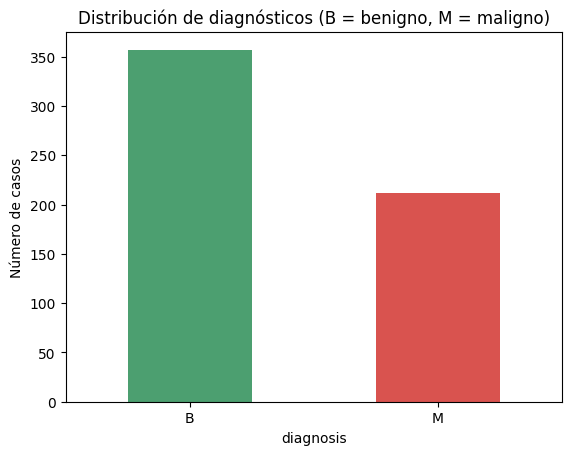

In [7]:
# Distribución de la variable objetivo (diagnosis): M = maligno, B = benigno
conteo = df["diagnosis"].value_counts()
porcentaje = df["diagnosis"].value_counts(normalize=True) * 100

resumen = pd.DataFrame({"casos": conteo, "porcentaje_%": porcentaje.round(1)})
print(resumen)

conteo.plot(kind="bar", color=["#4C9F70", "#D9534F"], rot=0)
plt.title("Distribución de diagnósticos (B = benigno, M = maligno)")
plt.ylabel("Número de casos")
plt.show()

In [8]:
# Estadísticos descriptivos de las variables numéricas
df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


## 3. Preparar X e y
- **X**: las características (variables predictoras).
- **y**: lo que queremos predecir. Lo convertimos a número: `1` = maligno, `0` = benigno.
- Se eliminan `id` (solo es un identificador) y `Unnamed: 32` (columna vacía que trae el CSV de Kaggle).

In [9]:
df_limpio = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

y = (df_limpio["diagnosis"] == "M").astype(int)   # 1 = maligno, 0 = benigno
X = df_limpio.drop(columns=["diagnosis"])

print(f"X: {X.shape[0]} filas x {X.shape[1]} variables")
print(f"y: {y.shape[0]} etiquetas  ->  malignos: {y.sum()}  |  benignos: {(y == 0).sum()}")
print(f"Nulos en X: {X.isnull().sum().sum()}")
X.head()

X: 569 filas x 30 variables
y: 569 etiquetas  ->  malignos: 212  |  benignos: 357
Nulos en X: 0


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Separar entrenamiento y prueba
80 % para entrenar y 20 % para evaluar. `stratify=y` mantiene la misma proporción de malignos/benignos en ambos grupos.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} casos")
print(f"Prueba:        {X_test.shape[0]} casos")

Entrenamiento: 455 casos
Prueba:        114 casos


## 5. Buscar el mejor modelo
Se hacen dos búsquedas, siempre con validación cruzada sobre `X_train` (el set de prueba no se toca hasta el final):
- **5.1** Búsqueda de hiperparámetros de CatBoost. El mejor queda guardado en `modelo`, que es el que usan las secciones 6 a 10.
- **5.2** Comparación de algoritmos: regresión logística, Random Forest, XGBoost y CatBoost.
- **5.3** Confirmación del ganador con el set de prueba.

### 5.1 Búsqueda de hiperparámetros de CatBoost
Prueba 15 combinaciones al azar de `depth`, `learning_rate`, `iterations` y `l2_leaf_reg`. Puntúa con **log-loss** porque interesa que las probabilidades sean buenas, no solo que ordenen bien. Puede tardar 1 o 2 minutos.

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

modelo_base = CatBoostClassifier(
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

param_grid = {
    "depth": [3, 4, 5, 6],
    "learning_rate": [0.02, 0.05, 0.1],
    "iterations": [200, 300, 500],
    "l2_leaf_reg": [1, 3, 5, 9],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busqueda = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_grid,
    n_iter=15,                                   # combinaciones a probar
    scoring={"log_loss": "neg_log_loss", "auc": "roc_auc"},
    refit="log_loss",                            # elige la de mejores probabilidades
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)
busqueda.fit(X_train, y_train)

# Las 5 mejores combinaciones
resultados = pd.DataFrame(busqueda.cv_results_)
resultados["log_loss"] = -resultados["mean_test_log_loss"]
resultados["auc"] = resultados["mean_test_auc"]
cols = ["param_depth", "param_learning_rate", "param_iterations",
        "param_l2_leaf_reg", "log_loss", "auc"]
print(resultados.sort_values("log_loss")[cols].head(5).round(4).to_string(index=False))

print("\nMejores parametros:", busqueda.best_params_)

# El mejor modelo (ya reentrenado con todo X_train) reemplaza al anterior
modelo = busqueda.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
 param_depth  param_learning_rate  param_iterations  param_l2_leaf_reg  log_loss    auc
           3                 0.05               300                  5    0.0839 0.9931
           3                 0.02               300                  1    0.0867 0.9934
           4                 0.02               500                  5    0.0891 0.9931
           4                 0.02               300                  3    0.0910 0.9923
           5                 0.05               300                  9    0.0933 0.9928

Mejores parametros: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 3}


### 5.2 Comparar algoritmos
Se evalúan 4 modelos con la **misma validación cruzada** que en 5.1. Si dos modelos difieren menos que el `±` (desviación entre particiones), están prácticamente empatados.

`modelo` sigue siendo CatBoost porque la explicación SHAP de la sección 10 solo funciona con CatBoost.

In [12]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

params_cat = busqueda.best_params_              # mejores parametros de la busqueda 5.1

modelos = {
    "Regresion logistica": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                             eval_metric="logloss", random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(**params_cat, loss_function="Logloss",
                                   random_seed=RANDOM_STATE, verbose=False,
                                   allow_writing_files=False),
}

scoring = {"log_loss": "neg_log_loss", "auc": "roc_auc", "brier": "neg_brier_score"}

filas = []
for nombre, m in modelos.items():
    r = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring)   # mismo cv de 5.1
    filas.append({
        "modelo": nombre,
        "log_loss": -r["test_log_loss"].mean(),
        "log_loss_std": r["test_log_loss"].std(),
        "auc": r["test_auc"].mean(),
        "brier": -r["test_brier"].mean(),
    })
    print(f"{nombre} listo")

comparacion = pd.DataFrame(filas).sort_values("log_loss").reset_index(drop=True)
comparacion.round(4)

Regresion logistica listo
Random Forest listo
XGBoost listo
CatBoost listo


,modelo,log_loss,log_loss_std,auc,brier
0,Regresion logistica,0.0724,0.0233,0.9958,0.0191
1,CatBoost,0.0839,0.0214,0.9931,0.0217
2,XGBoost,0.0859,0.0302,0.9936,0.0230
3,Random Forest,0.1243,0.0272,0.9880,0.0319


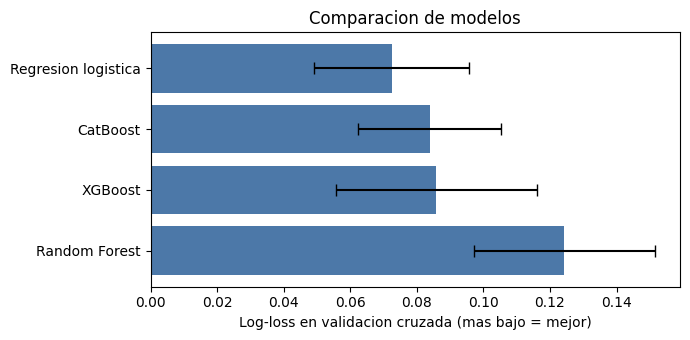

In [13]:
plt.figure(figsize=(7, 3.5))
plt.barh(comparacion["modelo"][::-1], comparacion["log_loss"][::-1],
         xerr=comparacion["log_loss_std"][::-1], color="#4C78A8", capsize=4)
plt.xlabel("Log-loss en validacion cruzada (mas bajo = mejor)")
plt.title("Comparacion de modelos")
plt.tight_layout()
plt.show()

### 5.3 Confirmar con el set de prueba
Se entrena el ganador de la validación cruzada y se compara en el set de prueba contra el CatBoost afinado (`modelo`), que es el que se usa en el resto del cuaderno.

In [14]:
ganador = comparacion.loc[0, "modelo"]
print(f"Mejor modelo en validacion cruzada: {ganador}")

modelo_ganador = modelos[ganador].fit(X_train, y_train)

def metricas_test(m):
    p = m.predict_proba(X_test)[:, 1]
    return {"AUC": roc_auc_score(y_test, p),
            "log_loss": log_loss(y_test, p),
            "brier": brier_score_loss(y_test, p)}

tabla_test = pd.DataFrame({
    f"Ganador en CV ({ganador})": metricas_test(modelo_ganador),
    "CatBoost afinado (modelo)": metricas_test(modelo),
}).T.round(4)
tabla_test

Mejor modelo en validacion cruzada: Regresion logistica


,AUC,log_loss,brier
Ganador en CV (Regresion logistica),0.996,0.0773,0.0213
CatBoost afinado (modelo),0.998,0.0835,0.0246


## 6. Predicciones en porcentaje
`predict_proba` devuelve la probabilidad de cada clase; nos quedamos con la de **maligno**.

In [15]:
proba_test = modelo.predict_proba(X_test)[:, 1]   # probabilidad de "maligno"
pred_test = (proba_test >= 0.5).astype(int)       # etiqueta con umbral de 50 %

ejemplos = pd.DataFrame({
    "Probabilidad_maligno_%": (proba_test[:10] * 100).round(1),
    "Etiqueta_real": np.where(y_test.values[:10] == 1, "Maligno", "Benigno"),
})
ejemplos

,Probabilidad_maligno_%,Etiqueta_real
0,0.2,Benigno
1,99.9,Maligno
2,6.2,Benigno
3,89.2,Maligno
4,2.1,Benigno
5,1.1,Benigno
6,79.5,Maligno
7,0.2,Benigno
8,0.1,Benigno
9,0.2,Benigno


## 7. Métricas de confiabilidad
- **AUC-ROC**: 1.0 = perfecto, 0.5 = azar.
- **Log-loss** y **Brier score**: miden qué tan buenas son las probabilidades (más bajo = mejor).

In [16]:
auc = roc_auc_score(y_test, proba_test)
ll = log_loss(y_test, proba_test)
brier = brier_score_loss(y_test, proba_test)

print(f"AUC-ROC:      {auc:.4f}")
print(f"Log-loss:     {ll:.4f}")
print(f"Brier score:  {brier:.4f}")

print("\n--- Reporte de clasificación (umbral 0.5) ---")
print(classification_report(y_test, pred_test, target_names=["Benigno", "Maligno"]))

print("Matriz de confusión (filas = real, columnas = predicho) [Benigno, Maligno]:")
print(confusion_matrix(y_test, pred_test))

AUC-ROC:      0.9980
Log-loss:     0.0835
Brier score:  0.0246

--- Reporte de clasificación (umbral 0.5) ---
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de confusión (filas = real, columnas = predicho) [Benigno, Maligno]:
[[72  0]
 [ 4 38]]


## 8. Importancia de variables

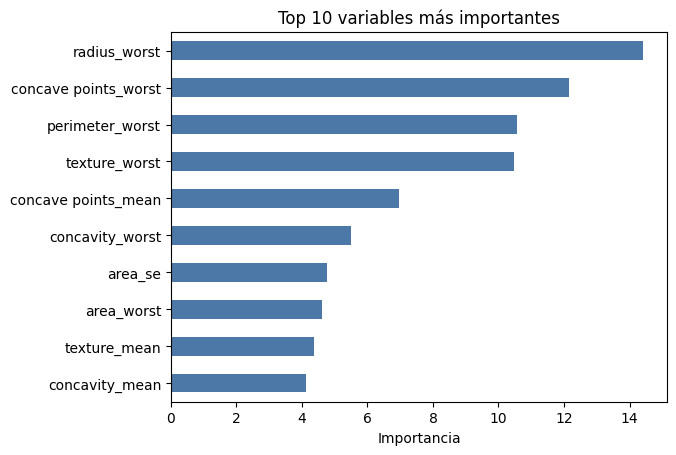

In [17]:
importancias = pd.Series(
    modelo.get_feature_importance(), index=X.columns
).sort_values(ascending=False)

importancias.head(10).sort_values().plot(kind="barh", color="#4C78A8")
plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.show()

## 9. Gráficos: curva ROC y curva de calibración
La curva de calibración responde: *si el modelo dice 80 %, ¿realmente ocurre el 80 % de las veces?*

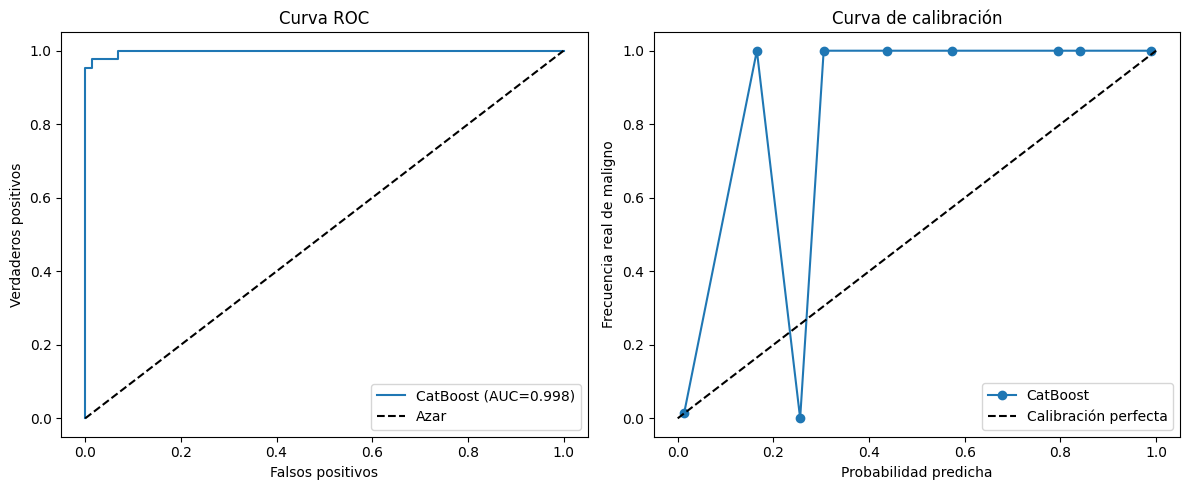

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, label=f"CatBoost (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Azar")
axes[0].set_xlabel("Falsos positivos")
axes[0].set_ylabel("Verdaderos positivos")
axes[0].set_title("Curva ROC")
axes[0].legend()

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10)
axes[1].plot(mean_pred, frac_pos, "o-", label="CatBoost")
axes[1].plot([0, 1], [0, 1], "k--", label="Calibración perfecta")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia real de maligno")
axes[1].set_title("Curva de calibración")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Analizar un caso: cuál es y por qué da esa probabilidad
Cambia el número de `indice` para analizar otro caso del set de prueba (de 0 a 113). Esta celda muestra **qué caso es** y todos sus valores.

In [19]:
from catboost import Pool

indice = 0   # <- cambia este número para analizar otro caso del set de prueba

caso = X_test.iloc[[indice]]
fila_original = X_test.index[indice]          # fila de este caso en el CSV original
prob = modelo.predict_proba(caso)[0, 1] * 100
real = "Maligno" if y_test.iloc[indice] == 1 else "Benigno"

print(f"Caso analizado: posicion {indice} del set de prueba (fila {fila_original} del CSV)")
if "id" in df.columns:
    print(f"ID del paciente en el dataset: {df.loc[fila_original, 'id']}")
print()
print(f"Probabilidad de que sea maligno: {prob:.1f}%")
print(f"Probabilidad de que sea benigno: {100 - prob:.1f}%")
print(f"Prediccion del modelo (umbral 50%): {'Maligno' if prob >= 50 else 'Benigno'}")
print(f"Etiqueta real: {real}")

# Los 30 valores de este caso
caso.T.set_axis(["valor_del_caso"], axis=1)

Caso analizado: posicion 0 del set de prueba (fila 120 del CSV)
ID del paciente en el dataset: 865137

Probabilidad de que sea maligno: 0.2%
Probabilidad de que sea benigno: 99.8%
Prediccion del modelo (umbral 50%): Benigno
Etiqueta real: Benigno


,valor_del_caso
radius_mean,11.410000
texture_mean,10.820000
perimeter_mean,73.340000
area_mean,403.300000
smoothness_mean,0.093730
compactness_mean,0.066850
concavity_mean,0.035120
concave points_mean,0.026230
symmetry_mean,0.166700
fractal_dimension_mean,0.061130


### ¿Cómo se explica la probabilidad de un caso?
CatBoost calcula el **aporte de cada variable** a la predicción (valores SHAP). Los números concretos salen de las celdas siguientes y cambian según el modelo y el caso que elijas en `indice`.

**El punto de partida**
- Es el promedio de las puntuaciones internas (log-odds) que el modelo dio a todos los casos de entrenamiento, convertido a porcentaje con la sigmoide.
- No coincide con el porcentaje de malignos de los datos, porque el promedio se hace en log-odds y no en porcentajes.
- Es un ancla matemática: representa un caso "promedio" antes de mirar sus variables.

**Del punto de partida a la predicción final**
- Cada una de las 30 variables suma o resta un aporte a la puntuación.
- Fórmula: `punto de partida + suma de aportes = predicción final` (en log-odds).
- Aporte negativo: empuja hacia benigno. Aporte positivo: empuja hacia maligno.
- Cuanto mayor es el valor absoluto del aporte, más pesó esa variable.

**Por qué puede parecer un salto**
- Si casi todas las variables empujan al mismo lado, la evidencia se acumula.
- Muchas variables miden cosas parecidas (área, perímetro y radio miden el tamaño), así que se refuerzan entre sí.
- La sigmoide comprime los extremos: los mismos pasos en log-odds quitan muchos puntos porcentuales al inicio y muy pocos al final.

In [20]:
shap_vals = modelo.get_feature_importance(Pool(caso), type="ShapValues")[0]
valor_base = shap_vals[-1]                        # punto de partida
aportes = pd.Series(shap_vals[:-1], index=X.columns)

sigmoide = lambda z: 1 / (1 + np.exp(-z))
prob_base = sigmoide(valor_base) * 100
prob_check = sigmoide(valor_base + aportes.sum()) * 100

print(f"Punto de partida (sin mirar ninguna variable): {prob_base:.1f}% de ser maligno")
print(f"Despues de sumar el aporte de las 30 variables: {prob_check:.1f}% de ser maligno")
print(f"(coincide con la prediccion del modelo: {prob:.1f}%)")

Punto de partida (sin mirar ninguna variable): 19.8% de ser maligno
Despues de sumar el aporte de las 30 variables: 0.2% de ser maligno
(coincide con la prediccion del modelo: 0.2%)


### ¿De dónde sale el punto de partida?
Comprobación: el `valor_base` de SHAP es el promedio de las puntuaciones internas (log-odds) del modelo sobre los datos de entrenamiento.

In [21]:
raw_train = modelo.predict(X_train, prediction_type="RawFormulaVal")

print(f"Promedio de puntuaciones internas en entrenamiento (log-odds): {raw_train.mean():.3f}")
print(f"valor_base de SHAP:                                            {valor_base:.3f}")
print(f"Convertido a porcentaje:                                       {sigmoide(raw_train.mean()) * 100:.1f}%")
print()
print(f"Promedio de las probabilidades en entrenamiento: {sigmoide(raw_train).mean() * 100:.1f}%  (distinto, por la curva de la sigmoide)")
print(f"Porcentaje real de malignos en entrenamiento:    {y_train.mean() * 100:.1f}%")

Promedio de puntuaciones internas en entrenamiento (log-odds): -1.396
valor_base de SHAP:                                            -1.396
Convertido a porcentaje:                                       19.8%

Promedio de las probabilidades en entrenamiento: 37.3%  (distinto, por la curva de la sigmoide)
Porcentaje real de malignos en entrenamiento:    37.4%


In [22]:
top = aportes.reindex(aportes.abs().sort_values(ascending=False).index).head(10)

tabla = pd.DataFrame({
    "valor_del_caso": caso.iloc[0][top.index].round(3),
    "prom_benignos": X_train[y_train == 0][top.index].mean().round(3),
    "prom_malignos": X_train[y_train == 1][top.index].mean().round(3),
    "aporte": top.round(3),
    "empuja_hacia": np.where(top > 0, "Maligno", "Benigno"),
})
tabla

,valor_del_caso,prom_benignos,prom_malignos,aporte,empuja_hacia
texture_worst,15.970,23.716,29.574,-1.029,Benigno
radius_worst,12.820,13.411,21.281,-0.617,Benigno
area_se,10.500,21.352,74.686,-0.614,Benigno
texture_mean,10.820,18.049,21.713,-0.584,Benigno
perimeter_worst,83.740,87.219,142.465,-0.540,Benigno
concave points_worst,0.090,0.075,0.183,-0.522,Benigno
area_worst,510.500,561.812,1441.721,-0.411,Benigno
concavity_worst,0.210,0.170,0.452,0.362,Maligno
concave points_mean,0.026,0.025,0.089,-0.344,Benigno
smoothness_worst,0.155,0.124,0.145,0.343,Maligno


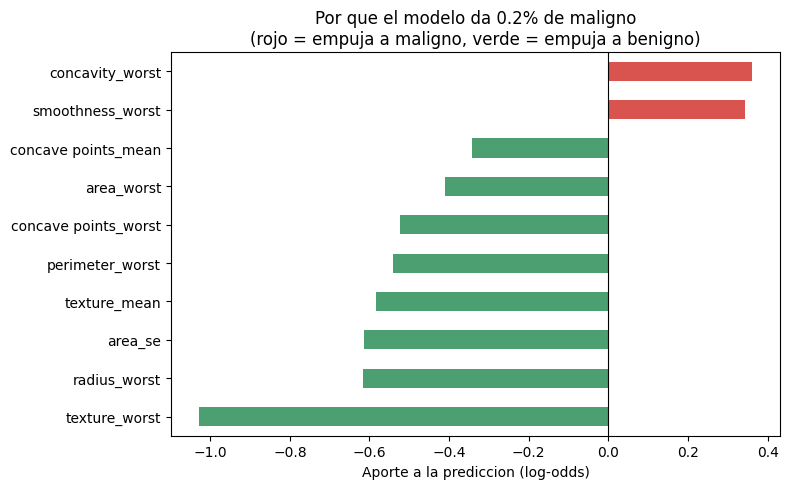

In [23]:
top_plot = top.sort_values()
colores = ["#D9534F" if v > 0 else "#4C9F70" for v in top_plot]

top_plot.plot(kind="barh", color=colores, figsize=(8, 5))
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Por que el modelo da {prob:.1f}% de maligno\n(rojo = empuja a maligno, verde = empuja a benigno)")
plt.xlabel("Aporte a la prediccion (log-odds)")
plt.tight_layout()
plt.show()

### ¿Cómo se acumula la evidencia variable por variable?
Se agregan las variables de mayor a menor peso y se muestra cómo cambia la probabilidad de maligno en cada paso.

In [24]:
orden = aportes.abs().sort_values(ascending=False).index
acumulado = valor_base + aportes[orden].cumsum()

pasos = pd.DataFrame({
    "variable_agregada": orden,
    "aporte": aportes[orden].round(3).values,
    "probabilidad_maligno_%": (sigmoide(acumulado) * 100).round(1).values,
})
print(f"Punto de partida: {sigmoide(valor_base) * 100:.1f}% de ser maligno")
pasos.head(12)

Punto de partida: 19.8% de ser maligno


,variable_agregada,aporte,probabilidad_maligno_%
0,texture_worst,-1.029,8.1
1,radius_worst,-0.617,4.6
2,area_se,-0.614,2.5
3,texture_mean,-0.584,1.4
4,perimeter_worst,-0.540,0.8
5,concave points_worst,-0.522,0.5
6,area_worst,-0.411,0.3
7,concavity_worst,0.362,0.5
8,concave points_mean,-0.344,0.3
9,smoothness_worst,0.343,0.5


### Conclusiones de la comparación de modelos

**Resultado**
- En validación cruzada, la regresión logística obtuvo el menor log-loss (0.072), seguida de CatBoost (0.084), XGBoost (0.086) y Random Forest (0.124).
- En el set de prueba, todos los modelos principales superaron un AUC de 0.99.

**Interpretación**
- Los datos son casi linealmente separables: los tumores malignos se distinguen de los benignos por valores claramente mayores en variables de tamaño e irregularidad celular.
- Cuando la frontera es casi lineal, un modelo simple generaliza mejor que uno de árboles, que necesita más datos para aproximarla.
- Con pocos casos (455 de entrenamiento), los modelos de árboles tienen más varianza. La curva de aprendizaje muestra que la diferencia a favor de la regresión logística se reduce al aumentar los datos.
- Random Forest tiene las probabilidades menos calibradas, por eso su log-loss es el más alto.

**Precauciones**
- Las diferencias entre regresión logística, CatBoost y XGBoost son pequeñas (aprox. 0.01 de log-loss) y comparables a la variación entre particiones.
- Solo CatBoost se afinó con búsqueda de hiperparámetros. La regresión logística, XGBoost y Random Forest usaron valores por defecto o fijos.
- El set de prueba tiene solo 114 casos, así que sus métricas son ruidosas. CatBoost tuvo mejor AUC en prueba (0.998 vs 0.996) y peor log-loss (0.0835 vs 0.0773).
- Este dataset es fácil y limpio. Estas conclusiones no se generalizan a datos más ruidosos o complejos.

**Decisión**
- Rendimiento y simplicidad: la regresión logística. Se explica con sus coeficientes.
- Se mantiene CatBoost en las secciones 6 a 10 porque permite explicar cada caso con valores SHAP.